<a href="https://colab.research.google.com/github/Sage0320/Machine-learning_Basic/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_2%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- 임의 데이터프레임 생성

In [1]:
import numpy as np #numpy: 행렬계산, 다차원계산할때 사용함.
import pandas as pd #pandas: 데이터 분석할때, 표 형태의 데이터 분석할때

# 스케일링, 폴리노미얼, 라벨인코딩, SMOTE
from sklearn.preprocessing import StandardScaler, MinMaxScaler # 둘은 스케일링할때 필요
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder # polynomialfeatures는 다중회귀할때 필요, labelencoder는 범주형 데이터 처리할때
from imblearn.over_sampling import SMOTE #불균형 데이터 처리할때 사용

# VIF 계산용(다중 공선성 계산)
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# ----------------------------------------------------------
# 1) 임의 데이터프레임 생성
#    - 수치형 변수 2개, 범주형 변수 1개, 날짜변수 1개, 타깃 변수(불균형) 1개
# ----------------------------------------------------------

np.random.seed(42)
N = 200

# 수치형 변수를 생성 (평균 50, 표준편차 10)
num1 = np.random.normal(loc=50, scale=10, size=N)
num2 = np.random.normal(loc=100, scale=20, size=N)

# 범주형 변수 (A, B, C 중 무작위)
cat_col = np.random.choice(['A', 'B', 'C'], size=N)

# 날짜변수(최근 200일 내 임의 날짜) 생성
date_rng = pd.date_range('2025-01-01', periods=N, freq='D')
print(date_rng)
#np.random.shuffle(date_rng)  # 날짜 순서 랜덤화

# 불균형 타깃(1이 10%, 0이 90%라고 가정)
#   - 실제로 1이 대략 20개, 0이 180개
target = np.random.choice([0,1], p=[0.9, 0.1], size=N)

# 데이터프레임 구성
df = pd.DataFrame({
    'num1': num1,
    'num2': num2,
    'cat_col': cat_col,
    'date_col': date_rng,
    'target': target
})

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-07-10', '2025-07-11', '2025-07-12', '2025-07-13',
               '2025-07-14', '2025-07-15', '2025-07-16', '2025-07-17',
               '2025-07-18', '2025-07-19'],
              dtype='datetime64[ns]', length=200, freq='D')


In [3]:
df

,num1,num2,cat_col,date_col,target
0,54.967142,107.155747,C,2025-01-01,0
1,48.617357,111.215691,C,2025-01-02,0
2,56.476885,121.661025,A,2025-01-03,0
3,65.230299,121.076041,A,2025-01-04,0
4,47.658466,72.446613,C,2025-01-05,0
...,...,...,...,...,...
195,53.853174,90.616487,A,2025-07-15,0
196,41.161426,65.737309,B,2025-07-16,0
197,51.537251,127.077447,C,2025-07-17,0
198,50.582087,97.709203,A,2025-07-18,0


In [6]:
# ----------------------------------------------------------
# 2) 결측치 추가 & 이상치(Outlier) 주입
#    - 일부 값을 NaN으로 바꾸고, 극단값 몇 개 삽입
# ----------------------------------------------------------

# (2-1) 결측치 추가
missing_indices_num1 = np.random.choice(df.index, size=5, replace=False)  # 5개 결측
missing_indices_num2 = np.random.choice(df.index, size=5, replace=False)  # 5개 결측
missing_indices_cat = np.random.choice(df.index, size=3, replace=False)   # 3개 결측
missing_indices_date= np.random.choice(df.index, size=2, replace=False)   # 2개 결측

df.loc[missing_indices_num1, 'num1'] = np.nan
df.loc[missing_indices_num2, 'num2'] = np.nan
df.loc[missing_indices_cat, 'cat_col'] = np.nan
df.loc[missing_indices_date,'date_col'] = pd.NaT

# (2-2) 이상치(Outlier) 주입: num1, num2에 극단값
outlier_indices_num1 = np.random.choice(df.index, size=3, replace=False)
outlier_indices_num2 = np.random.choice(df.index, size=3, replace=False)
df.loc[outlier_indices_num1, 'num1'] = df['num1'].mean() + 8*df['num1'].std()
df.loc[outlier_indices_num2, 'num2'] = df['num2'].mean() + 10*df['num2'].std()

print("=== [원본 데이터 일부] ===")
print(df.head(10))
print()

=== [원본 데이터 일부] ===
         num1        num2 cat_col   date_col  target
0   54.967142  107.155747       C 2025-01-01       0
1   48.617357  111.215691       C 2025-01-02       0
2   56.476885  121.661025       A 2025-01-03       0
3   65.230299  121.076041       A 2025-01-04       0
4   47.658466   72.446613     NaN 2025-01-05       0
5  124.312205   81.243499       B 2025-01-06       0
6   65.792128  110.300705       A 2025-01-07       0
7   57.674347  110.275719       A 2025-01-08       0
8   45.305256  110.300954       C 2025-01-09       0
9   55.425600  177.054630       A 2025-01-10       0



In [7]:
df

,num1,num2,cat_col,date_col,target
0,54.967142,107.155747,C,2025-01-01,0
1,48.617357,111.215691,C,2025-01-02,0
2,56.476885,121.661025,A,2025-01-03,0
3,65.230299,121.076041,A,2025-01-04,0
4,47.658466,72.446613,NaN,2025-01-05,0
...,...,...,...,...,...
195,53.853174,90.616487,A,2025-07-15,0
196,41.161426,65.737309,B,2025-07-16,0
197,51.537251,127.077447,C,2025-07-17,0
198,50.582087,97.709203,A,2025-07-18,0


In [8]:
df.isnull().sum()

,0
num1,5
num2,5
cat_col,3
date_col,2
target,0


In [9]:
df.describe()

,num1,num2,date_col,target
count,195.000000,195.000000,198,200.000000
mean,50.844545,104.892493,2025-04-10 11:23:38.181818112,0.095000
min,23.802549,35.174653,2025-01-01 00:00:00,0.000000
25%,43.089611,88.082117,2025-02-19 06:00:00,0.000000
50%,50.582087,102.270347,2025-04-10 12:00:00,0.000000
75%,55.322508,115.336033,2025-05-30 18:00:00,0.000000
max,124.312205,299.679316,2025-07-19 00:00:00,1.000000
std,13.069380,31.394378,NaN,0.293951


결측치 처리 (머신러닝에서 결측값있으면 안돌아감, xgb 는 예외일 수 있음)

In [11]:

# ----------------------------------------------------------
# 3) 결측치 처리
#    (3-1) 일부 행 제거, (3-2) 평균·중앙값 등으로 대체
# ----------------------------------------------------------

df_dropna = df.dropna()  # 모든 컬럼 중 결측값이 있으면 제거

df_fillna = df.copy()
# 수치형은 열별 평균으로 대체 (mean)
df_fillna['num1'] = df_fillna['num1'].fillna(df_fillna['num1'].mean())
df_fillna['num2'] = df_fillna['num2'].fillna(df_fillna['num2'].mean())
# 범주형은 최빈값으로 대체 (mode)
most_freq_cat = df_fillna['cat_col'].mode().iloc[0]
df_fillna['cat_col'] = df_fillna['cat_col'].fillna(most_freq_cat)
# 날짜열은 제거하지 않고 그대로 둠(또는 임의 날짜로 대체 가능)
# -> 시연을 위해 NaT(결측)도 남겨둠

print("=== [결측치 제거 후 shape] ===")
print(df_dropna.shape)
print("=== [결측치 대체 후 shape] ===")
print(df_fillna.shape)
print()

=== [결측치 제거 후 shape] ===
(186, 5)
=== [결측치 대체 후 shape] ===
(200, 5)



In [14]:
df_fillna['cat_col'].mode()

,cat_col
0,B


이상치 제거

In [16]:
# ----------------------------------------------------------
# 4) 이상치 제거
#    - (4-1) 표준편차 기준 (mu ± 3*std)
#    - (4-2) IQR 기준
# ----------------------------------------------------------

df_outlier_std = df_dropna.copy()
mean_num1, std_num1 = df_outlier_std['num1'].mean(), df_outlier_std['num1'].std()
mean_num2, std_num2 = df_outlier_std['num2'].mean(), df_outlier_std['num2'].std()

# 임계값 설정: ±3σ
lower_num1, upper_num1 = mean_num1 - 3*std_num1, mean_num1 + 3*std_num1
lower_num2, upper_num2 = mean_num2 - 3*std_num2, mean_num2 + 3*std_num2

df_outlier_std = df_outlier_std[
    (df_outlier_std['num1'] >= lower_num1) & (df_outlier_std['num1'] <= upper_num1) &
    (df_outlier_std['num2'] >= lower_num2) & (df_outlier_std['num2'] <= upper_num2)
]

# (4-2) IQR 기반
df_outlier_iqr = df_dropna.copy()
Q1_num1 = df_outlier_iqr['num1'].quantile(0.25)
Q3_num1 = df_outlier_iqr['num1'].quantile(0.75)
IQR_num1 = Q3_num1 - Q1_num1

Q1_num2 = df_outlier_iqr['num2'].quantile(0.25)
Q3_num2 = df_outlier_iqr['num2'].quantile(0.75)
IQR_num2 = Q3_num2 - Q1_num2

low_num1 = Q1_num1 - 1.5*IQR_num1
up_num1  = Q3_num1 + 1.5*IQR_num1
low_num2 = Q1_num2 - 1.5*IQR_num2
up_num2  = Q3_num2 + 1.5*IQR_num2

df_outlier_iqr = df_outlier_iqr[
    (df_outlier_iqr['num1'] >= low_num1) & (df_outlier_iqr['num1'] <= up_num1) &
    (df_outlier_iqr['num2'] >= low_num2) & (df_outlier_iqr['num2'] <= up_num2)
]

print(f"=== [이상치 제거 전 shape] : {df_dropna.shape}")
print(f"=== [표준편차 기준 제거 후 shape] : {df_outlier_std.shape}")
print(f"=== [IQR 기준 제거 후 shape] : {df_outlier_iqr.shape}")
print()

# IQR은 엄격한 기준으로 이상치를 제거할 수 있다.


=== [이상치 제거 전 shape] : (186, 5)
=== [표준편차 기준 제거 후 shape] : (180, 5)
=== [IQR 기준 제거 후 shape] : (176, 5)



In [17]:
df

,num1,num2,cat_col,date_col,target
0,54.967142,107.155747,C,2025-01-01,0
1,48.617357,111.215691,C,2025-01-02,0
2,56.476885,121.661025,A,2025-01-03,0
3,65.230299,121.076041,A,2025-01-04,0
4,47.658466,72.446613,NaN,2025-01-05,0
...,...,...,...,...,...
195,53.853174,90.616487,A,2025-07-15,0
196,41.161426,65.737309,B,2025-07-16,0
197,51.537251,127.077447,C,2025-07-17,0
198,50.582087,97.709203,A,2025-07-18,0


In [18]:
df_outlier_iqr.describe()

,num1,num2,date_col,target
count,176.000000,176.000000,176,176.000000
mean,49.778808,102.299568,2025-04-11 20:43:38.181818112,0.090909
min,30.124311,57.522086,2025-01-01 00:00:00,0.000000
25%,43.874401,88.659613,2025-02-21 18:00:00,0.000000
50%,50.592195,102.480680,2025-04-12 12:00:00,0.000000
75%,54.860328,114.088628,2025-05-30 06:00:00,0.000000
max,71.904556,146.293171,2025-07-19 00:00:00,1.000000
std,8.826523,18.591784,NaN,0.288300


스케일링

In [19]:
# ----------------------------------------------------------
# 5) 스케일링: 표준화(StandardScaler), 정규화(MinMaxScaler)
#    - 예시로 df_outlier_iqr 를 사용
# ----------------------------------------------------------
# 트리기반 모델일때는 스케일링 안해도됨

df_scaled = df_outlier_iqr.copy()

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

df_scaled['num1_std'] = scaler_std.fit_transform(df_scaled[['num1']]) # 사이킬런은 통일성이 있어 다루기 편하다.
df_scaled['num2_std'] = scaler_std.fit_transform(df_scaled[['num2']])
df_scaled['num1_minmax'] = scaler_minmax.fit_transform(df_scaled[['num1']])
df_scaled['num2_minmax'] = scaler_minmax.fit_transform(df_scaled[['num2']])

print("=== [스케일링 결과 컬럼 확인] ===")
print(df_scaled[['num1','num1_std','num1_minmax','num2','num2_std','num2_minmax']].head())
print()

=== [스케일링 결과 컬럼 확인] ===
        num1  num1_std  num1_minmax        num2  num2_std  num2_minmax
0  54.967142  0.589489     0.594607  107.155747  0.261946     0.559120
1  48.617357 -0.131962     0.442627  111.215691  0.480942     0.604855
2  56.476885  0.761023     0.630742  121.661025  1.044370     0.722521
3  65.230299  1.755570     0.840253  121.076041  1.012815     0.715931
6  65.792128  1.819404     0.853701  110.300705  0.431587     0.594547



In [20]:
df_scaled

,num1,num2,cat_col,date_col,target,num1_std,num2_std,num1_minmax,num2_minmax
0,54.967142,107.155747,C,2025-01-01,0,0.589489,0.261946,0.594607,0.559120
1,48.617357,111.215691,C,2025-01-02,0,-0.131962,0.480942,0.442627,0.604855
2,56.476885,121.661025,A,2025-01-03,0,0.761023,1.044370,0.630742,0.722521
3,65.230299,121.076041,A,2025-01-04,0,1.755570,1.012815,0.840253,0.715931
6,65.792128,110.300705,A,2025-01-07,0,1.819404,0.431587,0.853701,0.594547
...,...,...,...,...,...,...,...,...,...
195,53.853174,90.616487,A,2025-07-15,0,0.462922,-0.630193,0.567945,0.372806
196,41.161426,65.737309,B,2025-07-16,0,-0.979091,-1.972192,0.264171,0.092544
197,51.537251,127.077447,C,2025-07-17,0,0.199791,1.336535,0.512514,0.783536
198,50.582087,97.709203,A,2025-07-18,0,0.091267,-0.247607,0.489652,0.452705


- 범주형 데이터 변환(예외: catboost: 카테고리 부스트: 트리기반 모델
)


In [22]:
# ----------------------------------------------------------
# 6) 범주형 데이터 변환 (원-핫, 라벨 인코딩)
#    - 라벨 인코딩: cat_col
#    - 원-핫 인코딩: cat_col (또는 라벨 인코딩 후 다른 DF에 적용 가능)
# ----------------------------------------------------------

df_cat = df_scaled.copy()

# (6-1) 라벨 인코딩 # 순서가 있을때 예) 학점, 순서가 없을때(출생지)는 라벨 인코딩 안됨
label_encoder = LabelEncoder()
df_cat['cat_label'] = label_encoder.fit_transform(df_cat['cat_col'])

# (6-2) 원-핫 인코딩 # True=1, false=0/ get_dummies를 통한 원-핫 인코딩
df_cat = pd.get_dummies(df_cat, columns=['cat_col'])

print("=== [라벨 인코딩 + 원핫 인코딩 결과 컬럼] ===")
print(df_cat.head())
print()


=== [라벨 인코딩 + 원핫 인코딩 결과 컬럼] ===
        num1        num2   date_col  target  num1_std  num2_std  num1_minmax  \
0  54.967142  107.155747 2025-01-01       0  0.589489  0.261946     0.594607   
1  48.617357  111.215691 2025-01-02       0 -0.131962  0.480942     0.442627   
2  56.476885  121.661025 2025-01-03       0  0.761023  1.044370     0.630742   
3  65.230299  121.076041 2025-01-04       0  1.755570  1.012815     0.840253   
6  65.792128  110.300705 2025-01-07       0  1.819404  0.431587     0.853701   

   num2_minmax  cat_label  cat_col_A  cat_col_B  cat_col_C  
0     0.559120          2      False      False       True  
1     0.604855          2      False      False       True  
2     0.722521          0       True      False      False  
3     0.715931          0       True      False      False  
6     0.594547          0       True      False      False  



In [24]:
df_cat

,num1,num2,date_col,target,num1_std,num2_std,num1_minmax,num2_minmax,cat_label,cat_col_A,cat_col_B,cat_col_C
0,54.967142,107.155747,2025-01-01,0,0.589489,0.261946,0.594607,0.559120,2,False,False,True
1,48.617357,111.215691,2025-01-02,0,-0.131962,0.480942,0.442627,0.604855,2,False,False,True
2,56.476885,121.661025,2025-01-03,0,0.761023,1.044370,0.630742,0.722521,0,True,False,False
3,65.230299,121.076041,2025-01-04,0,1.755570,1.012815,0.840253,0.715931,0,True,False,False
6,65.792128,110.300705,2025-01-07,0,1.819404,0.431587,0.853701,0.594547,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
195,53.853174,90.616487,2025-07-15,0,0.462922,-0.630193,0.567945,0.372806,0,True,False,False
196,41.161426,65.737309,2025-07-16,0,-0.979091,-1.972192,0.264171,0.092544,1,False,True,False
197,51.537251,127.077447,2025-07-17,0,0.199791,1.336535,0.512514,0.783536,2,False,False,True
198,50.582087,97.709203,2025-07-18,0,0.091267,-0.247607,0.489652,0.452705,0,True,False,False


- 파생변수 생성


In [25]:
# ----------------------------------------------------------
# 7) 파생변수 생성
#    - (7-1) 날짜 파생: 연, 월, 요일, 주말여부 등
#    - (7-2) 수치형 변수 조합
#
# ----------------------------------------------------------

df_feat = df_cat.copy()

# (7-1) 날짜 파생
df_feat['year'] = df_feat['date_col'].dt.year
df_feat['month'] = df_feat['date_col'].dt.month
df_feat['dayofweek'] = df_feat['date_col'].dt.dayofweek  # 월=0, 화=1, ...
df_feat['is_weekend'] = df_feat['dayofweek'].apply(lambda x: 1 if x>=5 else 0)

# (7-2) 수치형 변수 조합 예시: num1 + num2
df_feat['num_sum'] = df_feat['num1_std'] + df_feat['num2_std']


print("=== [파생 변수 생성 결과] ===")
print(df_feat[['date_col','year','month','dayofweek','is_weekend','num1','num2','num_sum']].head())
print()

=== [파생 변수 생성 결과] ===
    date_col  year  month  dayofweek  is_weekend       num1        num2  \
0 2025-01-01  2025      1          2           0  54.967142  107.155747   
1 2025-01-02  2025      1          3           0  48.617357  111.215691   
2 2025-01-03  2025      1          4           0  56.476885  121.661025   
3 2025-01-04  2025      1          5           1  65.230299  121.076041   
6 2025-01-07  2025      1          1           0  65.792128  110.300705   

    num_sum  
0  0.851434  
1  0.348980  
2  1.805393  
3  2.768385  
6  2.250990  



In [26]:
df_feat

,num1,num2,date_col,target,num1_std,num2_std,num1_minmax,num2_minmax,cat_label,cat_col_A,cat_col_B,cat_col_C,year,month,dayofweek,is_weekend,num_sum
0,54.967142,107.155747,2025-01-01,0,0.589489,0.261946,0.594607,0.559120,2,False,False,True,2025,1,2,0,0.851434
1,48.617357,111.215691,2025-01-02,0,-0.131962,0.480942,0.442627,0.604855,2,False,False,True,2025,1,3,0,0.348980
2,56.476885,121.661025,2025-01-03,0,0.761023,1.044370,0.630742,0.722521,0,True,False,False,2025,1,4,0,1.805393
3,65.230299,121.076041,2025-01-04,0,1.755570,1.012815,0.840253,0.715931,0,True,False,False,2025,1,5,1,2.768385
6,65.792128,110.300705,2025-01-07,0,1.819404,0.431587,0.853701,0.594547,0,True,False,False,2025,1,1,0,2.250990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,53.853174,90.616487,2025-07-15,0,0.462922,-0.630193,0.567945,0.372806,0,True,False,False,2025,7,1,0,-0.167271
196,41.161426,65.737309,2025-07-16,0,-0.979091,-1.972192,0.264171,0.092544,1,False,True,False,2025,7,2,0,-2.951283
197,51.537251,127.077447,2025-07-17,0,0.199791,1.336535,0.512514,0.783536,2,False,False,True,2025,7,3,0,1.536326
198,50.582087,97.709203,2025-07-18,0,0.091267,-0.247607,0.489652,0.452705,0,True,False,False,2025,7,4,0,-0.156340


- 다중공선성 확인

In [28]:
# ----------------------------------------------------------
# 8) 다중공선성 확인 (상관관계, VIF)
#    - 예시로 수치형 변수(num1, num2, num_sum, num1_log 등)만 확인
# ----------------------------------------------------------

df_corr = df_feat[['target',	'num1_std',	'num2_std', 'cat_label', 'year',	'month',	'dayofweek',	'is_weekend', 'num_sum']].dropna()
print("=== [상관계수] ===")
print(df_corr.corr())

# VIF 계산 함수
def calc_vif(df_input):
    vif_data = []
    for i in range(df_input.shape[1]):
        vif = variance_inflation_factor(df_input.values, i)
        vif_data.append((df_input.columns[i], vif))
    return pd.DataFrame(vif_data, columns=['feature','VIF'])

vif_df = calc_vif(df_corr)
print("\n=== [VIF 결과] ===")
print(vif_df)
print()

=== [상관계수] ===
              target  num1_std  num2_std  cat_label  year     month  \
target      1.000000 -0.074645  0.082967   0.037486   NaN  0.010387   
num1_std   -0.074645  1.000000  0.064948  -0.037671   NaN  0.050411   
num2_std    0.082967  0.064948  1.000000   0.059277   NaN -0.016339   
cat_label   0.037486 -0.037671  0.059277   1.000000   NaN  0.068252   
year             NaN       NaN       NaN        NaN   NaN       NaN   
month       0.010387  0.050411 -0.016339   0.068252   NaN  1.000000   
dayofweek  -0.005526 -0.068253  0.063157   0.027986   NaN -0.020281   
is_weekend -0.023905 -0.011122  0.136693   0.039884   NaN -0.018208   
num_sum     0.005702  0.729708  0.729708   0.014804   NaN  0.023346   

            dayofweek  is_weekend   num_sum  
target      -0.005526   -0.023905  0.005702  
num1_std    -0.068253   -0.011122  0.729708  
num2_std     0.063157    0.136693  0.729708  
cat_label    0.027986    0.039884  0.014804  
year              NaN         NaN       NaN 

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [30]:
df_corr.corr() # 대각선은 자기 자신과의 상관관계라 의미가 없어 안봐도 된다.

,target,num1_std,num2_std,cat_label,year,month,dayofweek,is_weekend,num_sum
target,1.000000,-0.074645,0.082967,0.037486,NaN,0.010387,-0.005526,-0.023905,0.005702
num1_std,-0.074645,1.000000,0.064948,-0.037671,NaN,0.050411,-0.068253,-0.011122,0.729708
num2_std,0.082967,0.064948,1.000000,0.059277,NaN,-0.016339,0.063157,0.136693,0.729708
cat_label,0.037486,-0.037671,0.059277,1.000000,NaN,0.068252,0.027986,0.039884,0.014804
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,0.010387,0.050411,-0.016339,0.068252,NaN,1.000000,-0.020281,-0.018208,0.023346
dayofweek,-0.005526,-0.068253,0.063157,0.027986,NaN,-0.020281,1.000000,0.789815,-0.003492
is_weekend,-0.023905,-0.011122,0.136693,0.039884,NaN,-0.018208,0.789815,1.000000,0.086042
num_sum,0.005702,0.729708,0.729708,0.014804,NaN,0.023346,-0.003492,0.086042,1.000000


In [31]:
vif_df

,feature,VIF
0,target,1.016518
1,num1_std,inf
2,num2_std,inf
3,cat_label,1.012455
4,year,9.935030
5,month,1.008631
6,dayofweek,2.697191
7,is_weekend,2.728875
8,num_sum,inf


- 불균형 데이터 처리


In [32]:
# ----------------------------------------------------------
# 9) 불균형 데이터 처리: SMOTE (oversampling의 한 방법, 클래수 중 개수가 많은 쪽에 맞춰서 가는 방법)
#    - 타깃이 [0,1]로 되어 있고, 1이 매우 적은 상태
#    - SMOTE 적용 위해선 '피처'와 '타깃' 분리 필요
# ----------------------------------------------------------
#의료나 제조업에서 중요
df_smote = df_feat.copy().dropna(subset=['target'])  # 일단 이상치,결측 제거된 DF 사용
X = df_smote[['num_sum', 'cat_label',	'year', 'month',	'dayofweek',	'is_weekend']]  # 간단히 수치형 2개만 피처로
y = df_smote['target'] # 독립변수와 종속변수 잘 구분해야함, 종속변수가 Y
# 예측 대상이 연속적인 숫자값인 경우 SMOTE 사용하면 안됨, 정상/이상 구분, 양성/음성 구분 -> 타켓이 범주형 형태일때 예측할때 SMPOTE 사용함.
print("=== [SMOTE 전 레이블 분포] ===")
print(y.value_counts())

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("=== [SMOTE 후 레이블 분포] ===")
print(pd.Series(y_res).value_counts())
print()


=== [SMOTE 전 레이블 분포] ===
target
0    160
1     16
Name: count, dtype: int64
=== [SMOTE 후 레이블 분포] ===
target
0    160
1    160
Name: count, dtype: int64



In [35]:
df_feat

,num1,num2,date_col,target,num1_std,num2_std,num1_minmax,num2_minmax,cat_label,cat_col_A,cat_col_B,cat_col_C,year,month,dayofweek,is_weekend,num_sum
0,54.967142,107.155747,2025-01-01,0,0.589489,0.261946,0.594607,0.559120,2,False,False,True,2025,1,2,0,0.851434
1,48.617357,111.215691,2025-01-02,0,-0.131962,0.480942,0.442627,0.604855,2,False,False,True,2025,1,3,0,0.348980
2,56.476885,121.661025,2025-01-03,0,0.761023,1.044370,0.630742,0.722521,0,True,False,False,2025,1,4,0,1.805393
3,65.230299,121.076041,2025-01-04,0,1.755570,1.012815,0.840253,0.715931,0,True,False,False,2025,1,5,1,2.768385
6,65.792128,110.300705,2025-01-07,0,1.819404,0.431587,0.853701,0.594547,0,True,False,False,2025,1,1,0,2.250990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,53.853174,90.616487,2025-07-15,0,0.462922,-0.630193,0.567945,0.372806,0,True,False,False,2025,7,1,0,-0.167271
196,41.161426,65.737309,2025-07-16,0,-0.979091,-1.972192,0.264171,0.092544,1,False,True,False,2025,7,2,0,-2.951283
197,51.537251,127.077447,2025-07-17,0,0.199791,1.336535,0.512514,0.783536,2,False,False,True,2025,7,3,0,1.536326
198,50.582087,97.709203,2025-07-18,0,0.091267,-0.247607,0.489652,0.452705,0,True,False,False,2025,7,4,0,-0.156340


<Axes: >

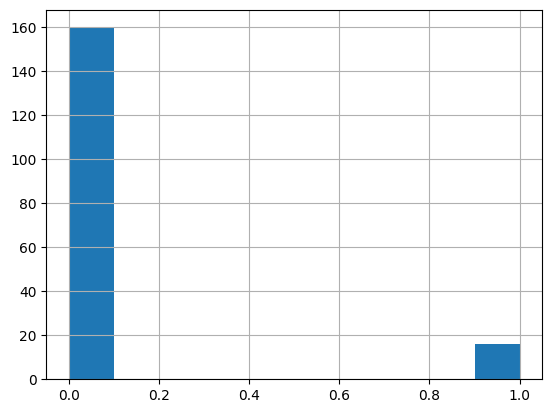

In [40]:
df_feat['target'].hist()

In [36]:
X_res

,num_sum,cat_label,year,month,dayofweek,is_weekend
0,0.851434,2,2025,1,2,0
1,0.348980,2,2025,1,3,0
2,1.805393,0,2025,1,4,0
3,2.768385,0,2025,1,5,1
4,2.250990,0,2025,1,1,0
...,...,...,...,...,...,...
315,-2.162074,2,2025,2,0,0
316,-1.632526,1,2025,4,1,0
317,-0.409221,1,2025,5,3,0
318,1.514062,1,2025,5,3,0


In [39]:
y_res

,target
0,0
1,0
2,0
3,0
4,0
...,...
315,1
316,1
317,1
318,1


<Axes: >

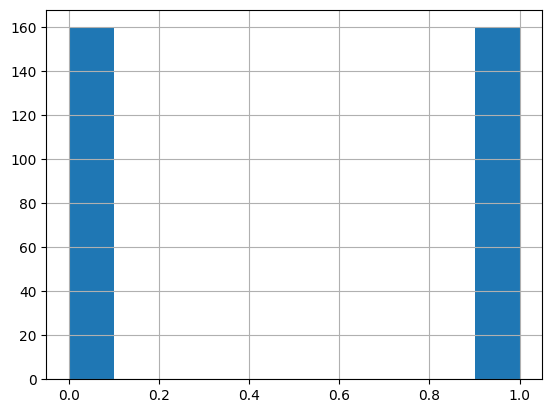

In [41]:
y_res.hist()